In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',  40)

In [2]:
conn = mysql.connector.connect(
    host='212.227.90.6',
    user='Equipo19',
    password='E1q2u3i4p5o19',
    database='Equip_19'
)

cursor = conn.cursor()

# Obtener nombres de tablas
cursor.execute("SHOW TABLES")
tablas = [t[0] for t in cursor.fetchall()]

# Guardar todas las tablas en un diccionario de DataFrames
dfs = {tabla: pd.read_sql(f"SELECT * FROM {tabla}", conn) for tabla in tablas}


df = dfs['Tourist_Accommodation03112025']

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18980\3161191244.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs = {tabla: pd.read_sql(f"SELECT * FROM {tabla}", conn) for tabla in tablas}


In [3]:
# df = pd.read_csv('Data_cleaning_27102025.csv')

# df

In [3]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date'],
      dtype='object')

<b>¿Qué aspectos (precisión, higiene, check-in o comunicación) presentan las mayores diferencias entre los alojamientos mejor y peor valorados en la evaluación general?</b>

Creo que debemos ver cuáles son los alojamientos mejor valorados y cuáles son los peor valorados y luego ver cuáles son los aspectos que tienen peor nota en esos alojamientos.

<i>Y luego en el Power BI ya pondría el selector por ciudad y también por tipo de habitación</i>

In [ ]:
nota_max = df['review_scores_rating'].max()

mejores = df.loc[df['review_scores_rating'] == nota_max,
                 ['apartment_id', 'review_scores_rating',
                  'review_scores_accuracy', 'review_scores_cleanliness',
                  'review_scores_checkin', 'review_scores_communication']]

mejores.head(10)

,apartment_id,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication
79,461943,1000.0,100.0,100.0,60.0,100.0
117,590991,1000.0,80.0,80.0,100.0,100.0
134,640268,1000.0,100.0,100.0,100.0,100.0
157,717300,1000.0,100.0,100.0,100.0,100.0
173,751527,1000.0,100.0,100.0,100.0,100.0
182,759577,1000.0,100.0,100.0,100.0,100.0
202,824609,1000.0,100.0,100.0,100.0,100.0
230,896291,1000.0,100.0,100.0,100.0,100.0
250,935836,1000.0,80.0,90.0,90.0,100.0
252,936871,1000.0,100.0,100.0,100.0,100.0


Puntuaciones de las categorías de los alojamientos con mejor nota general:
                             Mínimo  Máximo
review_scores_accuracy         60.0   100.0
review_scores_cleanliness      40.0   100.0
review_scores_checkin          40.0   100.0
review_scores_communication    20.0   100.0


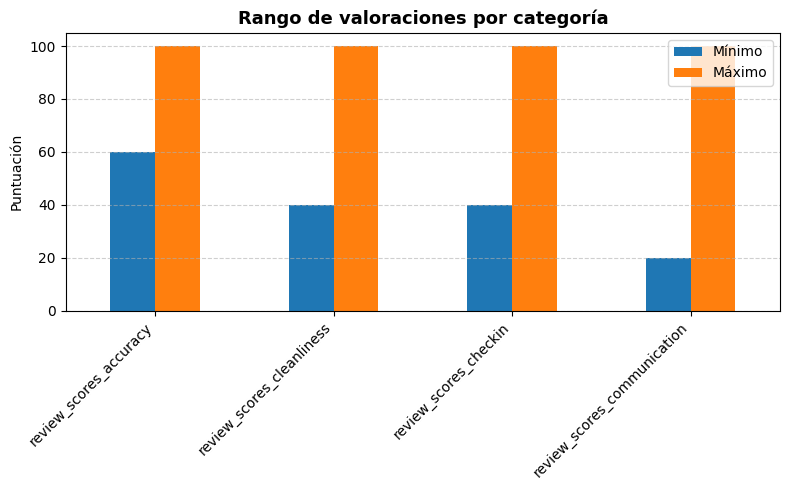

In [10]:
categorias = ['review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication']

resumen_top = pd.DataFrame({
    'Mínimo': mejores[categorias].min(),
    'Máximo': mejores[categorias].max()
}).round(2)

print("Puntuaciones de las categorías de los alojamientos con mejor nota general:")
print(resumen_top)

resumen_top[['Mínimo', 'Máximo']].plot(kind='bar', figsize=(8,5))
plt.title('Rango de valoraciones por categoría', fontsize=13, fontweight='bold')
plt.ylabel('Puntuación')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [6]:
nota_min = df['review_scores_rating'].min()

peores = df.loc[df['review_scores_rating'] == nota_min,
                 ['apartment_id', 'review_scores_rating',
                  'review_scores_accuracy', 'review_scores_cleanliness',
                  'review_scores_checkin', 'review_scores_communication']]

peores.tail(10)

,apartment_id,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication
4946,20438732,200.0,20.0,20.0,20.0,20.0
5232,21418557,200.0,20.0,20.0,20.0,20.0
5764,22995415,200.0,20.0,20.0,40.0,20.0
6729,26125080,200.0,20.0,40.0,60.0,20.0
7083,27603327,200.0,60.0,20.0,60.0,60.0
7135,27824712,200.0,20.0,60.0,80.0,80.0
7149,27943335,200.0,20.0,20.0,100.0,40.0
7173,28041055,200.0,20.0,20.0,20.0,20.0
7767,31306749,200.0,20.0,20.0,80.0,80.0
7957,32229216,200.0,60.0,20.0,80.0,80.0


Puntuaciones de las categorías de los alojamientos con peor nota general:
                             Mínimo  Máximo
review_scores_accuracy         20.0   100.0
review_scores_cleanliness      20.0   100.0
review_scores_checkin          20.0   100.0
review_scores_communication    20.0   100.0


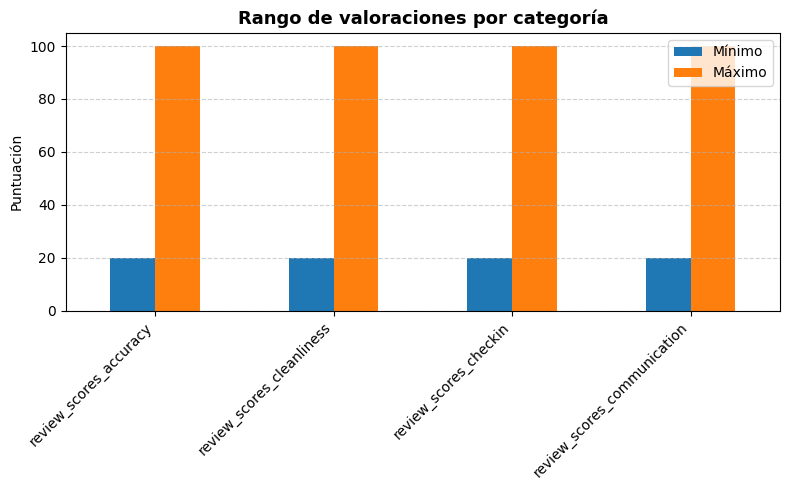

In [15]:
resumen_bottom = pd.DataFrame({
    'Mínimo': peores[categorias].min(),
    'Máximo': peores[categorias].max()
}).round(2)

print("Puntuaciones de las categorías de los alojamientos con peor nota general:")
print(resumen_bottom)

resumen_bottom[['Mínimo', 'Máximo']].plot(kind='bar', figsize=(8,5))
plt.title('Rango de valoraciones por categoría', fontsize=13, fontweight='bold')
plt.ylabel('Puntuación')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
